In [1]:
# library(MASS)     # para fitdistr e binomial negativa
library(tidyverse)
library(dplyr)
# library(ggplot2)
# library(stringr)
# library(tidyr)
# library(purrr)
# library(scales)
# library(fitdistrplus)  # para ajustar e comparar distribuições
# library(broom)
library(lme4)
# library(broom.mixed)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   4.0.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack




# Carregar dados

In [2]:
dados = read_csv("/home/aninha/Desktop/Doutorado/Dados/gabarito_foco_ausente.csv")
head(dados)
glimpse(dados)

Rows: 80480 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): cd_exame, faixa_etaria, regiao_sp, sexo, origem, dente_col
dbl (3): idade, ausente, dente

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


cd_exame,faixa_etaria,regiao_sp,idade,sexo,origem,dente_col,ausente,dente
<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>
alp.026080,20-44,Oeste,24,masculino,Alphaville,ausente_11,0,11
alp.026080,20-44,Oeste,24,masculino,Alphaville,ausente_12,0,12
alp.026080,20-44,Oeste,24,masculino,Alphaville,ausente_13,0,13
alp.026080,20-44,Oeste,24,masculino,Alphaville,ausente_14,0,14
alp.026080,20-44,Oeste,24,masculino,Alphaville,ausente_15,0,15
alp.026080,20-44,Oeste,24,masculino,Alphaville,ausente_16,0,16


Rows: 80,480
Columns: 9
$ cd_exame     <chr> "alp.026080", "alp.026080", "alp.026080", "alp.026080", "…
$ faixa_etaria <chr> "20-44", "20-44", "20-44", "20-44", "20-44", "20-44", "20…
$ regiao_sp    <chr> "Oeste", "Oeste", "Oeste", "Oeste", "Oeste", "Oeste", "Oe…
$ idade        <dbl> 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 2…
$ sexo         <chr> "masculino", "masculino", "masculino", "masculino", "masc…
$ origem       <chr> "Alphaville", "Alphaville", "Alphaville", "Alphaville", "…
$ dente_col    <chr> "ausente_11", "ausente_12", "ausente_13", "ausente_14", "…
$ ausente      <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ dente        <dbl> 11, 12, 13, 14, 15, 16, 17, 18, 21, 22, 23, 24, 25, 26, 2…


In [3]:
dados$faixa_etaria = factor(dados$faixa_etaria, ordered = FALSE)
dados$regiao_sp = factor(dados$regiao_sp, ordered = FALSE)
dados$sexo = factor(dados$sexo, ordered = FALSE)
dados$origem = factor(dados$origem, ordered = FALSE)
dados$dente = factor(dados$dente, ordered = FALSE)

dados$idade = as.integer(dados$idade)
dados$ausente = as.integer(dados$ausente)

In [4]:
glimpse(dados)

Rows: 80,480
Columns: 9
$ cd_exame     <chr> "alp.026080", "alp.026080", "alp.026080", "alp.026080", "…
$ faixa_etaria <fct> 20-44, 20-44, 20-44, 20-44, 20-44, 20-44, 20-44, 20-44, 2…
$ regiao_sp    <fct> Oeste, Oeste, Oeste, Oeste, Oeste, Oeste, Oeste, Oeste, O…
$ idade        <int> 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 2…
$ sexo         <fct> masculino, masculino, masculino, masculino, masculino, ma…
$ origem       <fct> Alphaville, Alphaville, Alphaville, Alphaville, Alphavill…
$ dente_col    <chr> "ausente_11", "ausente_12", "ausente_13", "ausente_14", "…
$ ausente      <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ dente        <fct> 11, 12, 13, 14, 15, 16, 17, 18, 21, 22, 23, 24, 25, 26, 2…


In [5]:
dim(dados)

[1] 80480     9

In [6]:
summary(dados)

   cd_exame         faixa_etaria   regiao_sp         idade      
 Length:80480       13-19:   64   Centro:26176   Min.   : 7.00  
 Class :character   20-44:32608   Leste :20320   1st Qu.:30.00  
 Mode  :character   45-74:43232   Norte :14304   Median :50.00  
                    5-12 :   32   Oeste : 8704   Mean   :48.22  
                    75+  : 4544   Sul   :10976   3rd Qu.:62.00  
                                                 Max.   :93.00  
                                                                
        sexo                origem       dente_col            ausente      
 feminino :48608   Santana     :14272   Length:80480       Min.   :0.0000  
 masculino:31872   Tatuape     :12864   Class :character   1st Qu.:0.0000  
                   Santo Amaro : 9184   Mode  :character   Median :0.0000  
                   Vila Mariana: 8736                      Mean   :0.2241  
                   Jardins     : 8608                      3rd Qu.:0.0000  
                   Jd. A

In [7]:
teste = dados[0:10000,]

# Adicionar classe de tipo de dente

In [8]:
library(dplyr)

add_tipo_dente <- function(df) {
  df %>%
    mutate(
      tipo_dente = case_when(
        dente %in% c(11, 21, 31, 41) ~ "Central incisor",
        dente %in% c(12, 22, 32, 42) ~ "Lateral incisor",
        
        dente %in% c(13, 23, 33, 43) ~ "Canine",
        
        dente %in% c(14, 24, 34, 44) ~ "First premolar",
        dente %in% c(15, 25, 35, 45) ~ "Second premolar",
        
        dente %in% c(16, 26, 36, 46) ~ "First molar",
        dente %in% c(17, 27, 37, 47) ~ "Second molar",
        dente %in% c(18, 28, 38, 48) ~ "Third molar",
        
        TRUE ~ NA_character_
      ),
      tipo_dente = factor(
        tipo_dente,
        levels = c(
          "Central incisor", "Lateral incisor", "Canine",
          "First premolar", "Second premolar",
          "First molar", "Second molar", "Third molar"
        ),
        ordered = TRUE
      )
    )
}

In [9]:
dados = add_tipo_dente(dados)
dados$tipo_dente = factor(dados$tipo_dente, ordered = FALSE)
head(dados)

cd_exame,faixa_etaria,regiao_sp,idade,sexo,origem,dente_col,ausente,dente,tipo_dente
<chr>,<fct>,<fct>,<int>,<fct>,<fct>,<chr>,<int>,<fct>,<fct>
alp.026080,20-44,Oeste,24,masculino,Alphaville,ausente_11,0,11,Central incisor
alp.026080,20-44,Oeste,24,masculino,Alphaville,ausente_12,0,12,Lateral incisor
alp.026080,20-44,Oeste,24,masculino,Alphaville,ausente_13,0,13,Canine
alp.026080,20-44,Oeste,24,masculino,Alphaville,ausente_14,0,14,First premolar
alp.026080,20-44,Oeste,24,masculino,Alphaville,ausente_15,0,15,Second premolar
alp.026080,20-44,Oeste,24,masculino,Alphaville,ausente_16,0,16,First molar


In [10]:
table(dados$tipo_dente)


Central incisor Lateral incisor          Canine  First premolar Second premolar 
          10060           10060           10060           10060           10060 
    First molar    Second molar     Third molar 
          10060           10060           10060 

# Modelo com dados de teste

In [11]:
# modelo <- glmer(
#     ausente ~ sexo + idade + origem + dente + (1 | cd_exame),
#     data = teste,
#     family = binomial(link = "logit"),
#     control = glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 1e5))
#   )

In [12]:
# modelo

In [13]:
# saveRDS(modelo, "/home/aninha/Desktop/Doutorado/Modelos/misto_R/modelo_glmer_sexo_idade_origem_dente.rds")

In [14]:
# modelo_carregado <- readRDS("/home/aninha/Desktop/Doutorado/Modelos/misto_R/modelo_glmer_sexo_idade_origem_dente.rds")

In [15]:
# modelo_carregado

In [16]:
# head(dados)

# Criar um subconjunto

In [17]:
glimpse(dados)

Rows: 80,480
Columns: 10
$ cd_exame     <chr> "alp.026080", "alp.026080", "alp.026080", "alp.026080", "…
$ faixa_etaria <fct> 20-44, 20-44, 20-44, 20-44, 20-44, 20-44, 20-44, 20-44, 2…
$ regiao_sp    <fct> Oeste, Oeste, Oeste, Oeste, Oeste, Oeste, Oeste, Oeste, O…
$ idade        <int> 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 2…
$ sexo         <fct> masculino, masculino, masculino, masculino, masculino, ma…
$ origem       <fct> Alphaville, Alphaville, Alphaville, Alphaville, Alphavill…
$ dente_col    <chr> "ausente_11", "ausente_12", "ausente_13", "ausente_14", "…
$ ausente      <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ dente        <fct> 11, 12, 13, 14, 15, 16, 17, 18, 21, 22, 23, 24, 25, 26, 2…
$ tipo_dente   <fct> Central incisor, Lateral incisor, Canine, First premolar,…


In [18]:
table(dados$faixa_etaria)

dados_limpos <- dados %>%
    filter(idade >= 20) %>%
    droplevels()

table(dados_limpos$faixa_etaria)


13-19 20-44 45-74  5-12   75+ 
   64 32608 43232    32  4544 


20-44 45-74   75+ 
32608 43232  4544 

In [19]:
dados_limpos$faixa_etaria

[1] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
   [13] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
   [25] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
   [37] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
   [49] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
   [61] 20-44 20-44 20-44 20-44 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
   [73] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
   [85] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
   [97] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [109] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [121] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [133] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [145] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [157] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [169] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [181] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [193] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [205] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [217] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [229] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [241] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [253] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [265] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [277] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [289] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [301] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [313] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 45-74 45-74 45-74 45-74
  [325] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [337] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [349] 45-74 45-74 45-74 45-74 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [361] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [373] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [385] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [397] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [409] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 45-74 45-74 45-74 45-74
  [421] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [433] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [445] 45-74 45-74 45-74 45-74 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [457] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [469] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [481] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [493] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [505] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [517] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [529] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [541] 20-44 20-44 20-44 20-44 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [553] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [565] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [577] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [589] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [6

In [20]:
library(dplyr)
library(lme4)

set.seed(123)  # para reprodutibilidade

# 1) Escolhe, por exemplo, 400 exames aleatórios
exames_sub <- dados_limpos %>%
  distinct(cd_exame) %>%       # pega uma linha por exame
  slice_sample(n = 400) %>%    # ajusta o n aqui
  pull(cd_exame)

# 2) Filtra os dados só para esses exames
dados_teste <- dados_limpos %>%
  filter(cd_exame %in% exames_sub)

nrow(dados_teste)
length(unique(dados_teste$cd_exame))

[1] 12800

[1] 400

In [21]:
dados_teste$faixa_etaria

[1] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
   [13] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
   [25] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
   [37] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
   [49] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
   [61] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
   [73] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
   [85] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
   [97] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [109] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [121] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 45-74 45-74 45-74 45-74
  [133] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [145] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [157] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [169] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [181] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [193] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [205] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [217] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [229] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [241] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [253] 20-44 20-44 20-44 20-44 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [265] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [277] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [289] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [301] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [313] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 45-74 45-74 45-74 45-74
  [325] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [337] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [349] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [361] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [373] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [385] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [397] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [409] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [421] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [433] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [445] 45-74 45-74 45-74 45-74 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [457] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [469] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [481] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [493] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [505] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 45-74 45-74 45-74 45-74
  [517] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [529] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [541] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [553] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [565] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [577] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [589] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [6

# Modelo Misto - Ausente

In [22]:
# 3) Ajusta o modelo no subconjunto
modelo_teste <- glmer(
  ausente ~ sexo + faixa_etaria + regiao_sp + tipo_dente + (1 | cd_exame),
  data   = dados_teste,
  family = binomial(link = "logit"),
  control = glmerControl(
    optimizer = "bobyqa",
    optCtrl   = list(maxfun = 1e4)  # menor para testar
  )
)

summary(modelo_teste)


Correlation matrix not shown by default, as p = 15 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: ausente ~ sexo + faixa_etaria + regiao_sp + tipo_dente + (1 |  
    cd_exame)
   Data: dados_teste
Control: glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 10000))

      AIC       BIC    logLik -2*log(L)  df.resid 
   9820.4    9939.7   -4894.2    9788.4     12784 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-5.1660 -0.4261 -0.2175 -0.0688 11.2732 

Random effects:
 Groups   Name        Variance Std.Dev.
 cd_exame (Intercept) 0.8643   0.9297  
Number of obs: 12800, groups:  cd_exame, 400

Fixed effects:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)               -4.44553    0.17047 -26.078  < 2e-16 ***
sexomasculino              0.01836    0.11319   0.162   0.8712    
faixa_etaria45-74          1.88721    0.11824  15.961  < 2e-16 ***
faixa_etaria75+            2.68928    0.25853  10.402  < 2e-16

In [23]:
coef(modelo_teste)

$cd_exame
           (Intercept) sexomasculino faixa_etaria45-74 faixa_etaria75+
alp.027806   -4.435402     0.0183594          1.887209        2.689277
alp.027988   -4.146612     0.0183594          1.887209        2.689277
alp.028268   -5.507155     0.0183594          1.887209        2.689277
alp.028468   -5.498264     0.0183594          1.887209        2.689277
alp.029432   -4.733188     0.0183594          1.887209        2.689277
alp.030710   -5.313689     0.0183594          1.887209        2.689277
alp.032592   -4.146612     0.0183594          1.887209        2.689277
alp.033427   -4.159396     0.0183594          1.887209        2.689277
bra.066226   -5.801720     0.0183594          1.887209        2.689277
bra.067194   -3.963746     0.0183594          1.887209        2.689277
bra.069809   -3.427612     0.0183594          1.887209        2.689277
bra.070163   -2.850557     0.0183594          1.887209        2.689277
bra.072588   -5.801720     0.0183594          1.887209        2.689

In [24]:
# Função para gerar tabela LaTeX dos efeitos fixos de um modelo glmer
make_fixed_effects_latex <- function(model,
                                     caption = "Fixed effects from mixed-effects logistic regression model.",
                                     label   = "tab:fixed_effects") {
  s <- summary(model)
  coefs <- as.data.frame(s$coefficients)
  coefs$term <- rownames(coefs)
  rownames(coefs) <- NULL
  
  # Calcula odds ratios e IC 95%
  coefs$OR      <- exp(coefs$Estimate)
  coefs$OR_low  <- exp(coefs$Estimate - 1.96 * coefs[["Std. Error"]])
  coefs$OR_high <- exp(coefs$Estimate + 1.96 * coefs[["Std. Error"]])
  
  # Função auxiliar para mapear nomes dos termos para rótulos em inglês
  term_labels <- function(term) {
    map <- c(
      "(Intercept)"              = "Intercept",
      "sexomasculino"           = "Sex: male",
      "faixa_etaria45-74"       = "Age 45–74 (vs 20–44)",
      "faixa_etaria75+"         = "Age 75+ (vs 20–44)",
      "regiao_spLeste"          = "Region: East",
      "regiao_spNorte"          = "Region: North",
      "regiao_spOeste"          = "Region: West",
      "regiao_spSul"            = "Region: South",
      "tipo_denteLateral incisor" = "Lateral incisor (vs central)",
      "tipo_denteCanine"        = "Canine",
      "tipo_denteFirst premolar"  = "First premolar",
      "tipo_denteSecond premolar" = "Second premolar",
      "tipo_denteFirst molar"     = "First molar",
      "tipo_denteSecond molar"    = "Second molar",
      "tipo_denteThird molar"     = "Third molar"
    )
    ifelse(term %in% names(map), map[term], term)
  }
  
  coefs$Label <- term_labels(coefs$term)
  
  # Formata números (ajuste os dígitos se quiser)
  fmt <- function(x, digits = 2) formatC(x, format = "f", digits = digits)
  
  coefs$OR_fmt      <- fmt(coefs$OR, 2)
  coefs$OR_low_fmt  <- fmt(coefs$OR_low, 2)
  coefs$OR_high_fmt <- fmt(coefs$OR_high, 2)
  coefs$p_fmt       <- ifelse(coefs$`Pr(>|z|)` < 0.001,
                              "<0.001",
                              fmt(coefs$`Pr(>|z|)`, 3))
  
  # Monta linhas da tabela LaTeX
  lines <- apply(coefs, 1, function(row) {
    paste0(
      row[["Label"]], " & ",
      row[["OR_fmt"]], " & ",
      row[["OR_low_fmt"]], "--", row[["OR_high_fmt"]], " & ",
      row[["p_fmt"]], " \\\\"
    )
  })
  
  body <- paste(lines, collapse = "\n")
  
  # Monta tabela completa em LaTeX
  latex_tab <- paste0(
"\\begin{table}[ht]\n",
"\\centering\n",
"\\begin{tabular}{lccc}\n",
"\\hline\n",
"Variable & OR & 95\\% CI & p-value \\\\\n",
"\\hline\n",
body, "\n",
"\\hline\n",
"\\end{tabular}\n",
"\\caption{", caption, "}\n",
"\\label{", label, "}\n",
"\\end{table}\n"
  )
  
  return(latex_tab)
}

latex_code <- make_fixed_effects_latex(modelo_teste)
cat(latex_code)


\begin{table}[ht]
\centering
\begin{tabular}{lccc}
\hline
Variable & OR & 95\% CI & p-value \\
\hline
Intercept & 0.01 & 0.01--0.02 & <0.001 \\
Sex: male & 1.02 & 0.82--1.27 & 0.871 \\
Age 45–74 (vs 20–44) & 6.60 & 5.24--8.32 & <0.001 \\
Age 75+ (vs 20–44) & 14.72 & 8.87--24.43 & <0.001 \\
Region: East & 1.24 & 0.92--1.65 & 0.152 \\
Region: North & 1.40 & 1.04--1.89 & 0.028 \\
Region: West & 1.30 & 0.88--1.92 & 0.182 \\
Region: South & 1.02 & 0.72--1.45 & 0.910 \\
Lateral incisor (vs central) & 1.12 & 0.86--1.47 & 0.403 \\
Canine & 0.45 & 0.32--0.62 & <0.001 \\
First premolar & 2.60 & 2.04--3.32 & <0.001 \\
Second premolar & 4.18 & 3.30--5.29 & <0.001 \\
First molar & 10.79 & 8.57--13.58 & <0.001 \\
Second molar & 5.72 & 4.53--7.22 & <0.001 \\
Third molar & 38.78 & 30.60--49.16 & <0.001 \\
\hline
\end{tabular}
\caption{Fixed effects from mixed-effects logistic regression model.}
\label{tab:fixed_effects}
\end{table}


In [25]:
check_overdispersion <- function(model) {
  rdf <- df.residual(model)
  rp <- residuals(model, type = "pearson")
  Pearson.chisq <- sum(rp^2)
  ratio <- Pearson.chisq / rdf
  pval <- pchisq(Pearson.chisq, df = rdf, lower.tail = FALSE)
  c(chisq = Pearson.chisq, ratio = ratio, rdf = rdf, p = pval)
}

check_overdispersion(modelo_teste)

chisq        ratio          rdf            p 
1.047225e+04 8.191681e-01 1.278400e+04 1.000000e+00

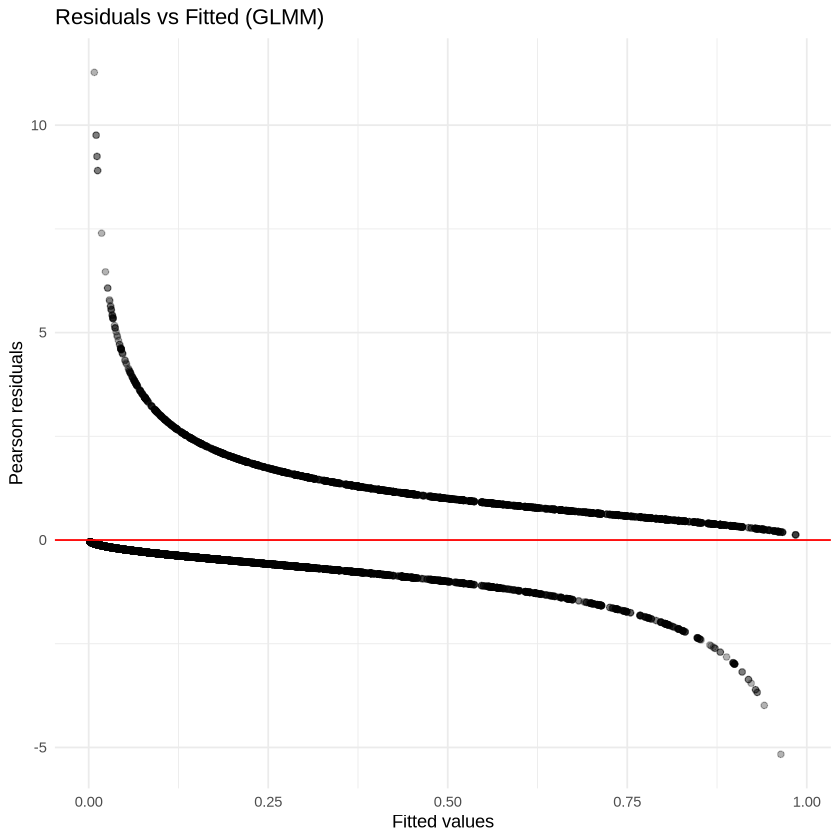

In [26]:
dados_teste$.fitted <- fitted(modelo_teste)
dados_teste$.pearson <- residuals(modelo_teste, type = "pearson")

library(ggplot2)

ggplot(dados_teste, aes(.fitted, .pearson)) +
  geom_point(alpha = 0.3) +
  geom_hline(yintercept = 0, color = "red") +
  labs(x = "Fitted values", y = "Pearson residuals",
       title = "Residuals vs Fitted (GLMM)") +
  theme_minimal()

# Modelo para carie

In [27]:
dados = read_csv("/home/aninha/Desktop/Doutorado/Dados/gabarito_foco_carie.csv")
head(dados)
glimpse(dados)

Rows: 160960 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): cd_exame, faixa_etaria, regiao_sp, sexo, origem, dente_col
dbl (4): idade, carie, dente, ausente

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


cd_exame,faixa_etaria,regiao_sp,idade,sexo,origem,dente_col,carie,dente,ausente
<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
alp.026080,20-44,Oeste,24,masculino,Alphaville,carie_report_11,0,11,0
alp.026080,20-44,Oeste,24,masculino,Alphaville,carie_report_12,0,12,0
alp.026080,20-44,Oeste,24,masculino,Alphaville,carie_report_13,0,13,0
alp.026080,20-44,Oeste,24,masculino,Alphaville,carie_report_14,1,14,1
alp.026080,20-44,Oeste,24,masculino,Alphaville,carie_report_15,0,15,0
alp.026080,20-44,Oeste,24,masculino,Alphaville,carie_report_16,0,16,0


Rows: 160,960
Columns: 10
$ cd_exame     <chr> "alp.026080", "alp.026080", "alp.026080", "alp.026080", "…
$ faixa_etaria <chr> "20-44", "20-44", "20-44", "20-44", "20-44", "20-44", "20…
$ regiao_sp    <chr> "Oeste", "Oeste", "Oeste", "Oeste", "Oeste", "Oeste", "Oe…
$ idade        <dbl> 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 2…
$ sexo         <chr> "masculino", "masculino", "masculino", "masculino", "masc…
$ origem       <chr> "Alphaville", "Alphaville", "Alphaville", "Alphaville", "…
$ dente_col    <chr> "carie_report_11", "carie_report_12", "carie_report_13", …
$ carie        <dbl> 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, …
$ dente        <dbl> 11, 12, 13, 14, 15, 16, 17, 18, 21, 22, 23, 24, 25, 26, 2…
$ ausente      <dbl> 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, …


In [28]:
dados = add_tipo_dente(dados)
dados$tipo_dente = factor(dados$tipo_dente, ordered = FALSE)
head(dados)

cd_exame,faixa_etaria,regiao_sp,idade,sexo,origem,dente_col,carie,dente,ausente,tipo_dente
<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<fct>
alp.026080,20-44,Oeste,24,masculino,Alphaville,carie_report_11,0,11,0,Central incisor
alp.026080,20-44,Oeste,24,masculino,Alphaville,carie_report_12,0,12,0,Lateral incisor
alp.026080,20-44,Oeste,24,masculino,Alphaville,carie_report_13,0,13,0,Canine
alp.026080,20-44,Oeste,24,masculino,Alphaville,carie_report_14,1,14,1,First premolar
alp.026080,20-44,Oeste,24,masculino,Alphaville,carie_report_15,0,15,0,Second premolar
alp.026080,20-44,Oeste,24,masculino,Alphaville,carie_report_16,0,16,0,First molar


In [29]:
table(dados$faixa_etaria)

dados_limpos <- dados %>%
    filter(idade >= 20) %>%
    droplevels()

table(dados_limpos$faixa_etaria)


13-19 20-44 45-74  5-12   75+ 
  128 65216 86464    64  9088 


20-44 45-74   75+ 
65216 86464  9088 

In [37]:
dados_limpos$faixa_etaria = factor(dados_limpos$faixa_etaria, ordered = FALSE)
dados_limpos$regiao_sp = factor(dados_limpos$regiao_sp, ordered = FALSE)
dados_limpos$sexo = factor(dados_limpos$sexo, ordered = FALSE)
dados_limpos$origem = factor(dados_limpos$origem, ordered = FALSE)
dados_limpos$dente = factor(dados_limpos$dente, ordered = FALSE)

dados_limpos$idade = as.integer(dados_limpos$idade)
dados_limpos$ausente = as.integer(dados_limpos$ausente)
dados_limpos$carie = as.integer(dados_limpos$carie)

In [31]:
set.seed(123)  # para reprodutibilidade

# 1) Escolhe, por exemplo, 400 exames aleatórios
exames_sub <- dados_limpos %>%
  distinct(cd_exame) %>%       # pega uma linha por exame
  slice_sample(n = 400) %>%    # ajusta o n aqui
  pull(cd_exame)

# 2) Filtra os dados só para esses exames
dados_teste <- dados_limpos %>%
  filter(cd_exame %in% exames_sub)

nrow(dados_teste)
length(unique(dados_teste$cd_exame))

[1] 25600

[1] 400

In [34]:
dados_teste %>%
  group_by(tipo_dente) %>%
  summarise(
    n = n(),
    carie_n = sum(carie == 1),
    carie_prop = mean(carie == 1)
  )

tipo_dente,n,carie_n,carie_prop
<fct>,<int>,<int>,<dbl>
Central incisor,3200,86,0.0268750
Lateral incisor,3200,110,0.0343750
Canine,3200,141,0.0440625
First premolar,3200,163,0.0509375
Second premolar,3200,194,0.0606250
First molar,3200,267,0.0834375
Second molar,3200,241,0.0753125
Third molar,3200,88,0.0275000


In [35]:
head(dados_teste)

cd_exame,faixa_etaria,regiao_sp,idade,sexo,origem,dente_col,carie,dente,ausente,tipo_dente
<chr>,<fct>,<fct>,<int>,<fct>,<fct>,<chr>,<dbl>,<fct>,<int>,<fct>
alp.027806,20-44,Oeste,29,masculino,Alphaville,carie_report_11,0,11,0,Central incisor
alp.027806,20-44,Oeste,29,masculino,Alphaville,carie_report_12,0,12,0,Lateral incisor
alp.027806,20-44,Oeste,29,masculino,Alphaville,carie_report_13,0,13,0,Canine
alp.027806,20-44,Oeste,29,masculino,Alphaville,carie_report_14,0,14,0,First premolar
alp.027806,20-44,Oeste,29,masculino,Alphaville,carie_report_15,0,15,0,Second premolar
alp.027806,20-44,Oeste,29,masculino,Alphaville,carie_report_16,1,16,1,First molar


In [38]:
glimpse(dados_teste)

Rows: 25,600
Columns: 11
$ cd_exame     <chr> "alp.027806", "alp.027806", "alp.027806", "alp.027806", "…
$ faixa_etaria <fct> 20-44, 20-44, 20-44, 20-44, 20-44, 20-44, 20-44, 20-44, 2…
$ regiao_sp    <fct> Oeste, Oeste, Oeste, Oeste, Oeste, Oeste, Oeste, Oeste, O…
$ idade        <int> 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 2…
$ sexo         <fct> masculino, masculino, masculino, masculino, masculino, ma…
$ origem       <fct> Alphaville, Alphaville, Alphaville, Alphaville, Alphavill…
$ dente_col    <chr> "carie_report_11", "carie_report_12", "carie_report_13", …
$ carie        <dbl> 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ dente        <fct> 11, 12, 13, 14, 15, 16, 17, 18, 21, 22, 23, 24, 25, 26, 2…
$ ausente      <int> 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ tipo_dente   <fct> Central incisor, Lateral incisor, Canine, First premolar,…


In [39]:
# 3) Ajusta o modelo no subconjunto
modelo_teste <- glmer(
  carie ~ sexo + faixa_etaria + regiao_sp + tipo_dente + (1 | cd_exame),
  data   = dados_teste,
  family = binomial(link = "logit"),
  control = glmerControl(
    optimizer = "bobyqa",
    optCtrl   = list(maxfun = 1e4)  # menor para testar
  )
)

summary(modelo_teste)


Correlation matrix not shown by default, as p = 15 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: carie ~ sexo + faixa_etaria + regiao_sp + tipo_dente + (1 | cd_exame)
   Data: dados_teste
Control: glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 10000))

      AIC       BIC    logLik -2*log(L)  df.resid 
   9518.3    9648.7   -4743.1    9486.3     25584 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-0.8544 -0.2501 -0.1785 -0.1242  9.8224 

Random effects:
 Groups   Name        Variance Std.Dev.
 cd_exame (Intercept) 0.7673   0.876   
Number of obs: 25600, groups:  cd_exame, 400

Fixed effects:
                           Estimate Std. Error z value Pr(>|z|)    
(Intercept)               -3.716302   0.166022 -22.384  < 2e-16 ***
sexomasculino              0.090017   0.114533   0.786 0.431896    
faixa_etaria45-74         -0.736567   0.114003  -6.461 1.04e-10 ***
faixa_etaria75+           -1.241609   0.306160  -4.055 5.00e-05 **

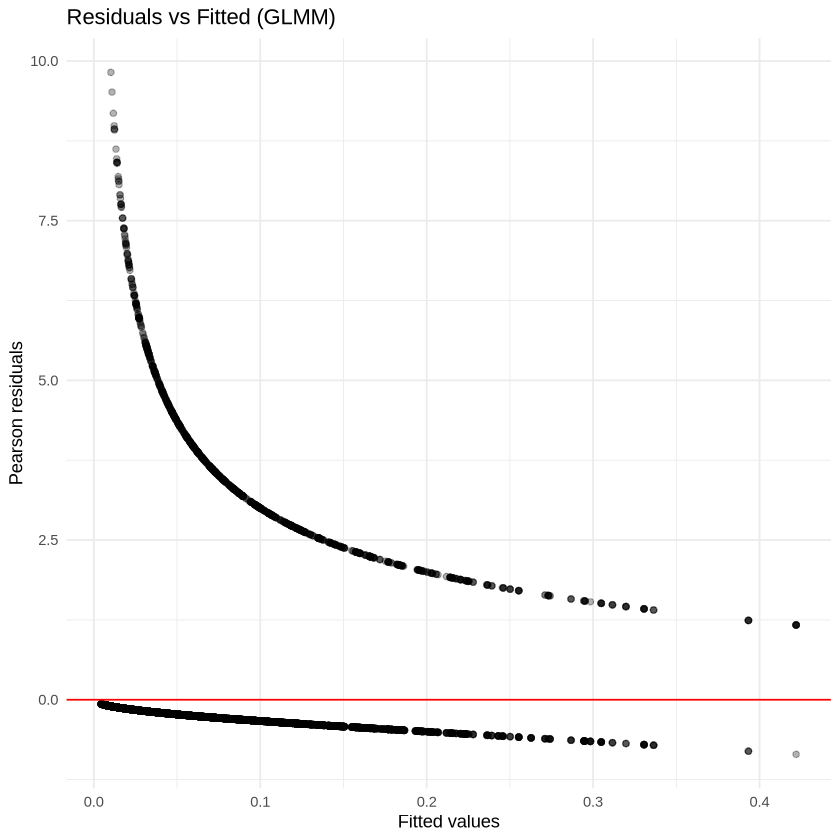

In [40]:
dados_teste$.fitted <- fitted(modelo_teste)
dados_teste$.pearson <- residuals(modelo_teste, type = "pearson")

library(ggplot2)

ggplot(dados_teste, aes(.fitted, .pearson)) +
  geom_point(alpha = 0.3) +
  geom_hline(yintercept = 0, color = "red") +
  labs(x = "Fitted values", y = "Pearson residuals",
       title = "Residuals vs Fitted (GLMM)") +
  theme_minimal()

In [41]:
latex_code <- make_fixed_effects_latex(modelo_teste)
cat(latex_code)

\begin{table}[ht]
\centering
\begin{tabular}{lccc}
\hline
Variable & OR & 95\% CI & p-value \\
\hline
Intercept & 0.02 & 0.02--0.03 & <0.001 \\
Sex: male & 1.09 & 0.87--1.37 & 0.432 \\
Age 45–74 (vs 20–44) & 0.48 & 0.38--0.60 & <0.001 \\
Age 75+ (vs 20–44) & 0.29 & 0.16--0.53 & <0.001 \\
Region: East & 1.39 & 1.04--1.87 & 0.026 \\
Region: North & 1.12 & 0.82--1.52 & 0.492 \\
Region: West & 1.01 & 0.68--1.50 & 0.964 \\
Region: South & 1.27 & 0.89--1.81 & 0.193 \\
Lateral incisor (vs central) & 1.30 & 0.98--1.72 & 0.070 \\
Canine & 1.70 & 1.30--2.22 & <0.001 \\
First premolar & 1.99 & 1.53--2.59 & <0.001 \\
Second premolar & 2.41 & 1.87--3.12 & <0.001 \\
First molar & 3.48 & 2.72--4.45 & <0.001 \\
Second molar & 3.09 & 2.41--3.96 & <0.001 \\
Third molar & 1.02 & 0.76--1.38 & 0.873 \\
\hline
\end{tabular}
\caption{Fixed effects from mixed-effects logistic regression model.}
\label{tab:fixed_effects}
\end{table}


# Modelo para obturado

In [60]:
dados = read_csv("/home/aninha/Desktop/Doutorado/Dados/gabarito_foco_obturado.csv")
head(dados)
glimpse(dados)

Rows: 80480 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): cd_exame, faixa_etaria, regiao_sp, sexo, origem, dente_col
dbl (4): idade, obturado, dente, ausente

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


cd_exame,faixa_etaria,regiao_sp,idade,sexo,origem,dente_col,obturado,dente,ausente
<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
alp.026080,20-44,Oeste,24,masculino,Alphaville,obturado_11,0,11,0
alp.026080,20-44,Oeste,24,masculino,Alphaville,obturado_12,0,12,0
alp.026080,20-44,Oeste,24,masculino,Alphaville,obturado_13,0,13,0
alp.026080,20-44,Oeste,24,masculino,Alphaville,obturado_14,0,14,0
alp.026080,20-44,Oeste,24,masculino,Alphaville,obturado_15,0,15,0
alp.026080,20-44,Oeste,24,masculino,Alphaville,obturado_16,1,16,1


Rows: 80,480
Columns: 10
$ cd_exame     <chr> "alp.026080", "alp.026080", "alp.026080", "alp.026080", "…
$ faixa_etaria <chr> "20-44", "20-44", "20-44", "20-44", "20-44", "20-44", "20…
$ regiao_sp    <chr> "Oeste", "Oeste", "Oeste", "Oeste", "Oeste", "Oeste", "Oe…
$ idade        <dbl> 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 2…
$ sexo         <chr> "masculino", "masculino", "masculino", "masculino", "masc…
$ origem       <chr> "Alphaville", "Alphaville", "Alphaville", "Alphaville", "…
$ dente_col    <chr> "obturado_11", "obturado_12", "obturado_13", "obturado_14…
$ obturado     <dbl> 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ dente        <dbl> 11, 12, 13, 14, 15, 16, 17, 18, 21, 22, 23, 24, 25, 26, 2…
$ ausente      <dbl> 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …


In [61]:
dados = add_tipo_dente(dados)
dados$tipo_dente = factor(dados$tipo_dente, ordered = FALSE)
head(dados)

cd_exame,faixa_etaria,regiao_sp,idade,sexo,origem,dente_col,obturado,dente,ausente,tipo_dente
<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<fct>
alp.026080,20-44,Oeste,24,masculino,Alphaville,obturado_11,0,11,0,Central incisor
alp.026080,20-44,Oeste,24,masculino,Alphaville,obturado_12,0,12,0,Lateral incisor
alp.026080,20-44,Oeste,24,masculino,Alphaville,obturado_13,0,13,0,Canine
alp.026080,20-44,Oeste,24,masculino,Alphaville,obturado_14,0,14,0,First premolar
alp.026080,20-44,Oeste,24,masculino,Alphaville,obturado_15,0,15,0,Second premolar
alp.026080,20-44,Oeste,24,masculino,Alphaville,obturado_16,1,16,1,First molar


In [62]:
table(dados$faixa_etaria)

dados_limpos <- dados %>%
    filter(idade >= 20) %>%
    droplevels()

table(dados_limpos$faixa_etaria)


13-19 20-44 45-74  5-12   75+ 
   64 32608 43232    32  4544 


20-44 45-74   75+ 
32608 43232  4544 

In [63]:
dados_limpos$faixa_etaria = factor(dados_limpos$faixa_etaria, ordered = FALSE)
dados_limpos$regiao_sp = factor(dados_limpos$regiao_sp, ordered = FALSE)
dados_limpos$sexo = factor(dados_limpos$sexo, ordered = FALSE)
dados_limpos$origem = factor(dados_limpos$origem, ordered = FALSE)
dados_limpos$dente = factor(dados_limpos$dente, ordered = FALSE)

dados_limpos$idade = as.integer(dados_limpos$idade)
dados_limpos$ausente = as.integer(dados_limpos$ausente)
dados_limpos$obturado = as.integer(dados_limpos$obturado)

In [64]:
set.seed(123)  # para reprodutibilidade

# 1) Escolhe, por exemplo, 400 exames aleatórios
exames_sub <- dados_limpos %>%
  distinct(cd_exame) %>%       # pega uma linha por exame
  slice_sample(n = 400) %>%    # ajusta o n aqui
  pull(cd_exame)

# 2) Filtra os dados só para esses exames
dados_teste <- dados_limpos %>%
  filter(cd_exame %in% exames_sub)

nrow(dados_teste)
length(unique(dados_teste$cd_exame))

[1] 12800

[1] 400

In [65]:
glimpse(dados_teste)

Rows: 12,800
Columns: 11
$ cd_exame     <chr> "alp.027806", "alp.027806", "alp.027806", "alp.027806", "…
$ faixa_etaria <fct> 20-44, 20-44, 20-44, 20-44, 20-44, 20-44, 20-44, 20-44, 2…
$ regiao_sp    <fct> Oeste, Oeste, Oeste, Oeste, Oeste, Oeste, Oeste, Oeste, O…
$ idade        <int> 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 2…
$ sexo         <fct> masculino, masculino, masculino, masculino, masculino, ma…
$ origem       <fct> Alphaville, Alphaville, Alphaville, Alphaville, Alphavill…
$ dente_col    <chr> "obturado_11", "obturado_12", "obturado_13", "obturado_14…
$ obturado     <int> 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, …
$ dente        <fct> 11, 12, 13, 14, 15, 16, 17, 18, 21, 22, 23, 24, 25, 26, 2…
$ ausente      <int> 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, …
$ tipo_dente   <fct> Central incisor, Lateral incisor, Canine, First premolar,…


In [66]:
dados_teste %>%
  group_by(tipo_dente) %>%
  summarise(
    n = n(),
    obturado_n = sum(obturado == 1),
    obturado_prop = mean(obturado == 1)
  )

tipo_dente,n,obturado_n,obturado_prop
<fct>,<int>,<int>,<dbl>
Central incisor,1600,394,0.246250
Lateral incisor,1600,368,0.230000
Canine,1600,309,0.193125
First premolar,1600,603,0.376875
Second premolar,1600,639,0.399375
First molar,1600,696,0.435000
Second molar,1600,766,0.478750
Third molar,1600,185,0.115625


In [67]:
table(dados_limpos$sexo)


 feminino masculino 
    48544     31840 

In [68]:
table(dados_limpos$regiao_sp)


Centro  Leste  Norte  Oeste    Sul 
 26144  20256  14304   8704  10976 

In [69]:
table(dados_limpos$faixa_etaria)
dados_limpos$faixa_etaria


20-44 45-74   75+ 
32608 43232  4544 

[1] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
   [13] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
   [25] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
   [37] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
   [49] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
   [61] 20-44 20-44 20-44 20-44 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
   [73] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
   [85] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
   [97] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [109] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [121] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [133] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [145] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [157] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [169] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [181] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [193] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [205] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [217] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [229] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [241] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [253] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [265] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [277] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [289] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [301] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [313] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 45-74 45-74 45-74 45-74
  [325] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [337] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [349] 45-74 45-74 45-74 45-74 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [361] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [373] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [385] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [397] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [409] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 45-74 45-74 45-74 45-74
  [421] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [433] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [445] 45-74 45-74 45-74 45-74 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [457] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [469] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [481] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [493] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [505] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [517] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [529] 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44 20-44
  [541] 20-44 20-44 20-44 20-44 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [553] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [565] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [577] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [589] 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74 45-74
  [6

In [70]:
# 3) Ajusta o modelo no subconjunto
modelo_teste <- glmer(
  obturado ~ sexo + faixa_etaria + regiao_sp + tipo_dente + (1 | cd_exame),
  data   = dados_teste,
  family = binomial(link = "logit"),
  control = glmerControl(
    optimizer = "bobyqa",
    optCtrl   = list(maxfun = 1e4)  # menor para testar
  )
)

summary(modelo_teste)


Correlation matrix not shown by default, as p = 15 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: obturado ~ sexo + faixa_etaria + regiao_sp + tipo_dente + (1 |  
    cd_exame)
   Data: dados_teste
Control: glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 10000))

      AIC       BIC    logLik -2*log(L)  df.resid 
  14056.9   14176.2   -7012.4   14024.9     12784 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.4469 -0.6281 -0.3908  0.8118  6.0998 

Random effects:
 Groups   Name        Variance Std.Dev.
 cd_exame (Intercept) 0.61     0.781   
Number of obs: 12800, groups:  cd_exame, 400

Fixed effects:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)               -1.27557    0.11970 -10.656  < 2e-16 ***
sexomasculino             -0.25216    0.09291  -2.714 0.006648 ** 
faixa_etaria45-74          0.44072    0.09289   4.745 2.09e-06 ***
faixa_etaria75+            0.09295    0.21954   0.423 0.67202

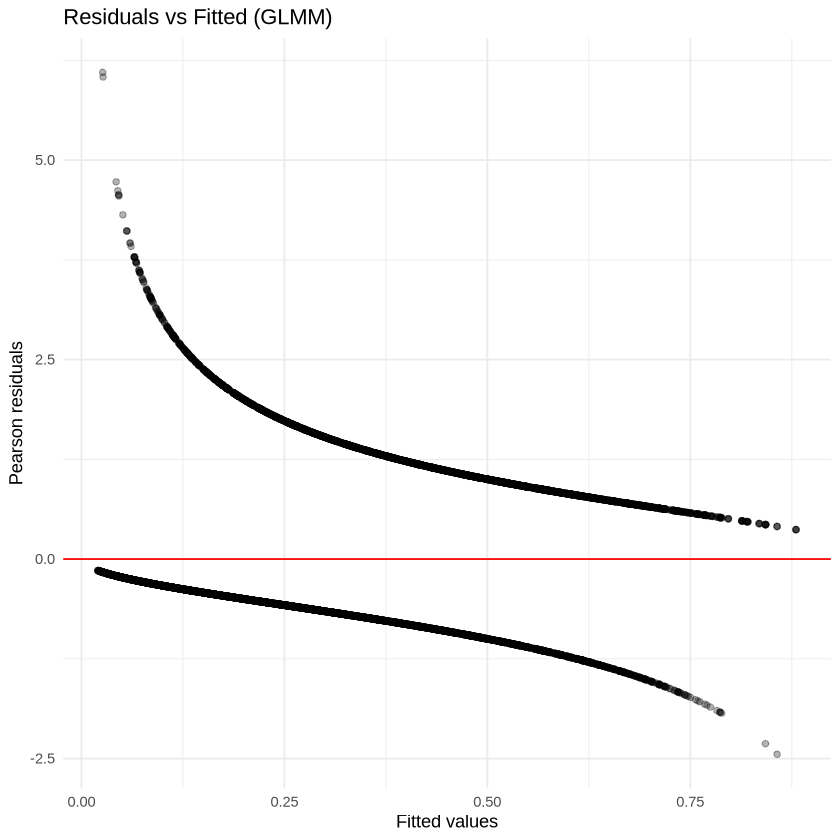

In [71]:
dados_teste$.fitted <- fitted(modelo_teste)
dados_teste$.pearson <- residuals(modelo_teste, type = "pearson")

library(ggplot2)

ggplot(dados_teste, aes(.fitted, .pearson)) +
  geom_point(alpha = 0.3) +
  geom_hline(yintercept = 0, color = "red") +
  labs(x = "Fitted values", y = "Pearson residuals",
       title = "Residuals vs Fitted (GLMM)") +
  theme_minimal()

In [72]:
latex_code <- make_fixed_effects_latex(modelo_teste)
cat(latex_code)

\begin{table}[ht]
\centering
\begin{tabular}{lccc}
\hline
Variable & OR & 95\% CI & p-value \\
\hline
Intercept & 0.28 & 0.22--0.35 & <0.001 \\
Sex: male & 0.78 & 0.65--0.93 & 0.007 \\
Age 45–74 (vs 20–44) & 1.55 & 1.30--1.86 & <0.001 \\
Age 75+ (vs 20–44) & 1.10 & 0.71--1.69 & 0.672 \\
Region: East & 0.73 & 0.57--0.92 & 0.009 \\
Region: North & 0.69 & 0.54--0.88 & 0.003 \\
Region: West & 0.77 & 0.56--1.06 & 0.103 \\
Region: South & 1.20 & 0.90--1.60 & 0.214 \\
Lateral incisor (vs central) & 0.90 & 0.76--1.07 & 0.252 \\
Canine & 0.71 & 0.59--0.84 & <0.001 \\
First premolar & 2.01 & 1.71--2.36 & <0.001 \\
Second premolar & 2.24 & 1.91--2.63 & <0.001 \\
First molar & 2.65 & 2.26--3.11 & <0.001 \\
Second molar & 3.25 & 2.77--3.82 & <0.001 \\
Third molar & 0.37 & 0.30--0.45 & <0.001 \\
\hline
\end{tabular}
\caption{Fixed effects from mixed-effects logistic regression model.}
\label{tab:fixed_effects}
\end{table}
